In [1]:
# if running on colab:
# !git clone https://github.com/laukamkit/capstone_project_GroupA.git
# cd capstone_project_GroupA/src

In [2]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from NSWData.NSWDataLoader import *
from ModelFiles.ModelPlots import *
nsw_data_loader = NSWDataLoader()

Found NSW data path: C:\Users\USER\Desktop\capstone_project_GroupA\data\NSW


In [3]:
# lstm_results_h48_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'LSTM_results', 'biLSTM_h48_test_results.csv'))
# lstm_results_h336_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'LSTM_results', 'biLSTM_h336_test_results.csv'))
# lstm_results_h720_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'LSTM_results', 'biLSTM_h720_test_results.csv'))
sarimax_results_h48_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'sarimax_results', 'sarimax_best_model_h48_test_results.csv'))
sarimax_results_h336_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'sarimax_results', 'sarimax_best_model_h336_test_results.csv'))
sarimax_results_h720_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'sarimax_results', 'sarimax_best_model_h720_test_results.csv'))

In [4]:
results_dict = {
    # 'LSTM': {
    #     48: lstm_results_h48_df,
    #     336: lstm_results_h336_df,
    #     720: lstm_results_h720_df
    # },
    'SARIMAX': {
        48: sarimax_results_h48_df,
        336: sarimax_results_h336_df,
        720: sarimax_results_h720_df
    },
    'ACTUALS': {
            48: sarimax_results_h48_df[['timestamp', 'horizon', 'y_actual']].rename(columns={'y_actual': 'y_pred'}),
            336: sarimax_results_h336_df[['timestamp', 'horizon', 'y_actual']].rename(columns={'y_actual': 'y_pred'}),
            720: sarimax_results_h720_df[['timestamp', 'horizon', 'y_actual']].rename(columns={'y_actual': 'y_pred'})
    }
}

In [5]:
CHOSEN_DATE_START = '2020-05-01 00:00:00'  # Set this to a date within the range of your results
HORIZON_TO_PLOT = 336  # Choose from 48, 336, or 720

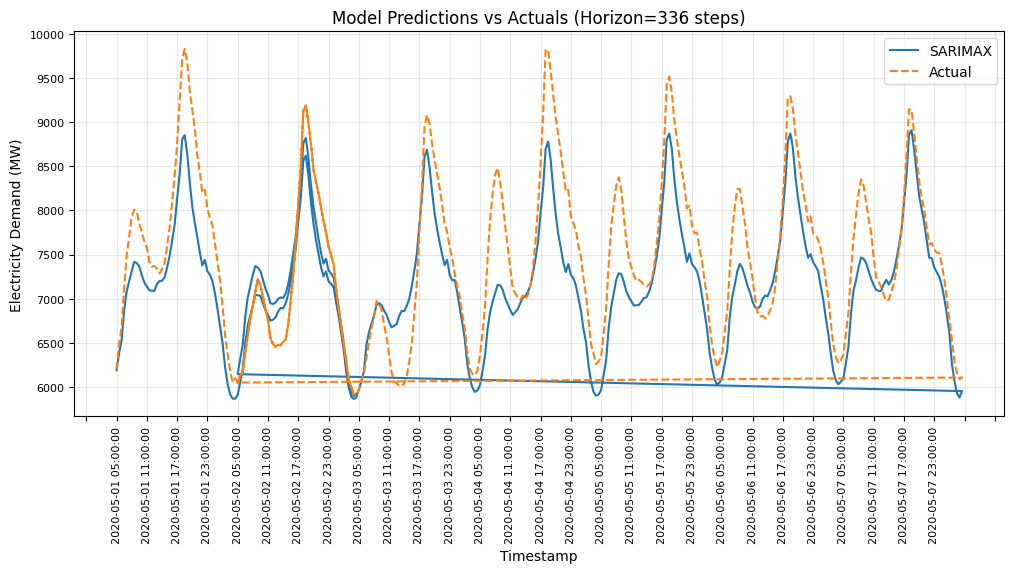

In [6]:
plot_predictions(results_dict, HORIZON_TO_PLOT, CHOSEN_DATE_START)

With provided forecast now (horizon=48 only)

In [7]:
forecast_h48_all_windows_df = pd.read_csv(os.path.join(nsw_data_loader.nsw_path, 'test.csv'))
HORIZON_WINDOWS = [f"P{str(i).zfill(2)}" for i in range(1,49)]
forecast_h48_all_windows_df = forecast_h48_all_windows_df[['DATETIME'] + HORIZON_WINDOWS]
forecast_h48_all_windows_df.head()

,DATETIME,P01,P02,P03,P04,P05,P06,P07,P08,P09,...,P39,P40,P41,P42,P43,P44,P45,P46,P47,P48
0,2019-03-03 05:00:00,6408.91,6376.06,6361.13,6388.21,6364.85,6364.50,6345.58,6323.31,6311.82,...,6394.42250,6388.94,6374.958,6368.132727,6352.0750,6337.368462,6332.028571,6330.779333,6329.03750,6320.052353
1,2019-03-03 05:30:00,6546.84,6562.59,6545.57,6504.15,6530.22,6499.37,6495.52,6476.40,6455.56,...,6506.81875,6499.54,6479.197,6470.239091,6447.2475,6425.707692,6417.972857,6414.924000,6411.97625,6402.203529
2,2019-03-03 06:00:00,6591.15,6656.47,6673.26,6649.71,6594.71,6609.58,6563.84,6559.69,6547.23,...,6619.21500,6610.14,6583.436,6572.345455,6542.4200,6514.046923,6503.917143,6499.068667,6494.91500,6484.354706
3,2019-03-03 06:30:00,6777.32,6773.73,6820.28,6807.27,6781.96,6724.78,6728.77,6687.94,6699.25,...,6731.61125,6720.74,6687.675,6674.451818,6637.5925,6602.386154,6589.861429,6583.213333,6577.85375,6566.505882
4,2019-03-03 07:00:00,6996.97,7008.74,6965.96,6981.40,6961.26,6929.36,6872.44,6867.71,6826.54,...,6844.00750,6831.34,6791.914,6776.558182,6732.7650,6690.725385,6675.805714,6667.358000,6660.79250,6648.657059


In [8]:
forecast_h48_df = forecast_h48_all_windows_df.copy()

# align the provided forecast with the forecast step size of the other models, which is 48.
forecast_h48_df = forecast_h48_df.loc[[i % 48 == 0 for i in range(len(forecast_h48_df))]].reset_index(drop=True)

# unpivot the windows from col to rows
forecast_h48_df = forecast_h48_df.melt('DATETIME').sort_values('DATETIME').reset_index(drop=True).reset_index()
forecast_h48_df.rename(columns={'index': 'horizon', 'DATETIME': 'timestamp', 'value': 'y_pred'}, inplace=True)
forecast_h48_df['horizon'] = forecast_h48_df['horizon'] % 48
forecast_h48_df['timestamp'] = pd.to_datetime(forecast_h48_df['timestamp']) + pd.to_timedelta(forecast_h48_df['horizon']*30, unit='m')
forecast_h48_df['timestamp'] = forecast_h48_df['timestamp'].astype(str)
forecast_h48_df.drop(columns=['variable'], inplace=True)
forecast_h48_df = forecast_h48_df[['timestamp','horizon','y_pred']]
forecast_h48_df = forecast_h48_df.loc[sarimax_results_h48_df.index]
forecast_h48_df

,timestamp,horizon,y_pred
0,2019-03-03 05:00:00,0,6408.910000
1,2019-03-03 05:30:00,1,6376.060000
2,2019-03-03 06:00:00,2,6361.130000
3,2019-03-03 06:30:00,3,6388.210000
4,2019-03-03 07:00:00,4,6364.850000
...,...,...,...
35755,2021-03-17 02:30:00,43,6306.412308
35756,2021-03-17 03:00:00,44,6277.092857
35757,2021-03-17 03:30:00,45,6256.368667
35758,2021-03-17 04:00:00,46,6244.483750


In [11]:
sarimax_results_h48_df.tail()

,origins,horizon,timestamp,y_actual,y_pred
35755,744,43,2021-03-17 02:30:00,5999.40,6098.856181
35756,744,44,2021-03-17 03:00:00,5964.12,6047.444789
35757,744,45,2021-03-17 03:30:00,5981.55,6050.183230
35758,744,46,2021-03-17 04:00:00,6051.72,6093.678926
35759,744,47,2021-03-17 04:30:00,6237.05,6272.563158


In [ ]:
results_dict_w_forecast = {
    # 'LSTM': {
    #     48: lstm_results_h48_df,
    #     336: lstm_results_h336_df,
    #     720: lstm_results_h720_df
    # },
    'SARIMAX': {
        48: sarimax_results_h48_df,
        336: sarimax_results_h336_df,
        720: sarimax_results_h720_df
    },
    'PROVIDED_FORECAST': {
        48: forecast_h48_df
    },
    'ACTUALS': {
            48: sarimax_results_h48_df[['timestamp', 'horizon', 'y_actual']].rename(columns={'y_actual': 'y_pred'}),
            336: sarimax_results_h336_df[['timestamp', 'horizon', 'y_actual']].rename(columns={'y_actual': 'y_pred'}),
            720: sarimax_results_h720_df[['timestamp', 'horizon', 'y_actual']].rename(columns={'y_actual': 'y_pred'})
    }
}

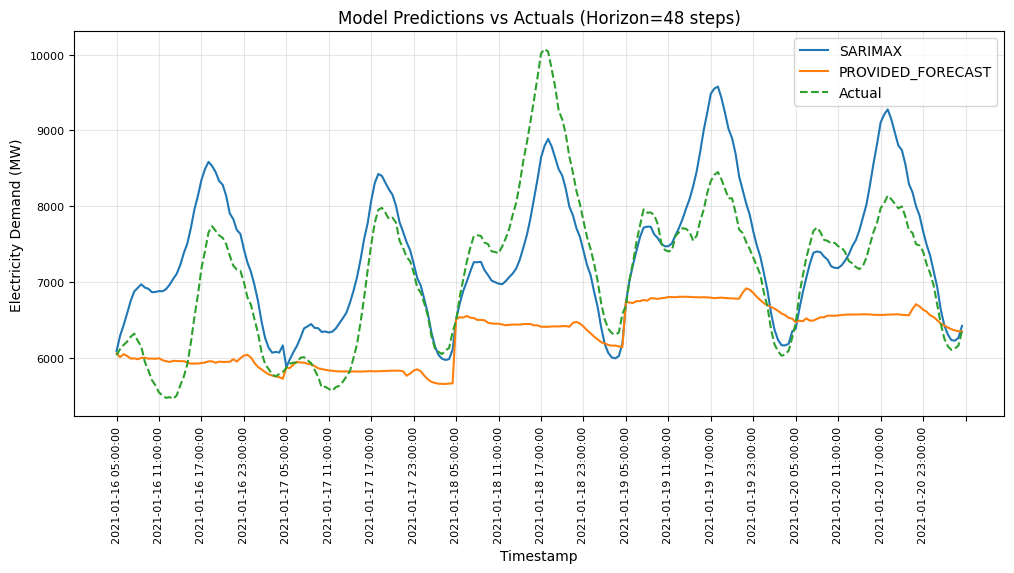

In [82]:
plot_predictions(results_dict_w_forecast, 48, '2021-01-16 04:30:00', extra_time_steps=48*4)

**Provided forecast looks a bit flat. Plot from raw forecast data to see whether if it's because of our pre-processing.**

In [76]:
df_forecast_og = pd.read_csv(os.path.join(nsw_data_loader.nsw_path, "forecastdemand_nsw.csv.zip"))
df_forecast_og.head()

,PREDISPATCHSEQNO,REGIONID,PERIODID,FORECASTDEMAND,LASTCHANGED,DATETIME
0,2009123018,NSW1,71,7832.04,2009-12-30 12:31:49,2010-01-01 00:00:00
1,2009123019,NSW1,70,7832.04,2009-12-30 13:01:43,2010-01-01 00:00:00
2,2009123020,NSW1,69,7832.03,2009-12-30 13:31:36,2010-01-01 00:00:00
3,2009123021,NSW1,68,7832.03,2009-12-30 14:01:44,2010-01-01 00:00:00
4,2009123022,NSW1,67,7830.96,2009-12-30 14:31:35,2010-01-01 00:00:00


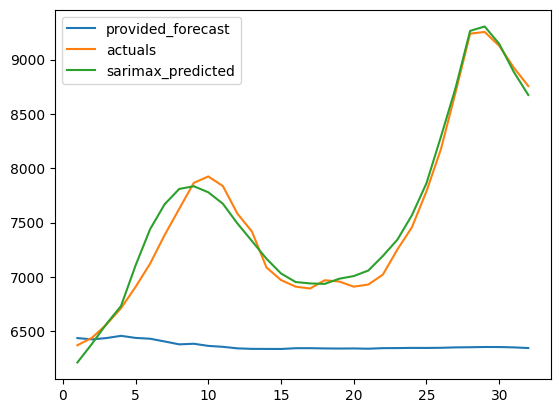

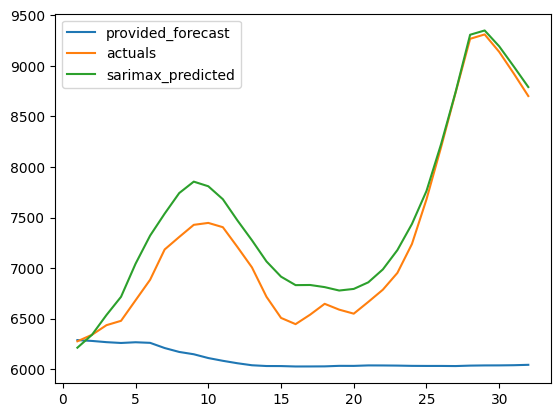

In [ ]:
START_DATE = '2020-05-16 04:30:00'
df_forecast = df_forecast_og[(df_forecast_og['DATETIME'] == START_DATE)][['DATETIME','PERIODID','FORECASTDEMAND']].sort_values('PERIODID')
sarimax_end_date = str(pd.Timedelta(minutes=30*(len(df_forecast)-1)) + pd.to_datetime(START_DATE))
plt.plot(range(1,len(df_forecast)+1), 
         df_forecast['FORECASTDEMAND'], 
         label='provided_forecast')
plt.plot(range(1,len(df_forecast)+1), 
         sarimax_results_h48_df[(sarimax_results_h48_df['timestamp'] >= START_DATE) & (sarimax_results_h48_df['timestamp'] <= sarimax_end_date)]['y_actual'], 
         label='actuals')
plt.plot(range(1,len(df_forecast)+1), 
         sarimax_results_h48_df[(sarimax_results_h48_df['timestamp'] >= START_DATE) & (sarimax_results_h48_df['timestamp'] <= sarimax_end_date)]['y_pred'], 
         label='sarimax_predicted')
plt.legend()
plt.show()